In [1]:
import numpy as np

# S_n implementation as mathematic formulas in 1.55

$$ S_n(t) = \sum_{p=0}^{n-1}d(t-2pT) $$

$ S_0(t) = 0 $ \
$ S_1(t) = d(t) $ \
$ S_2(t) = d(t) + d(t-2T) $

$S_n$ is a sum on $n$ elements where the first is 0 while the consecutive elements are a cumulative sum of distances between the mirrors in $2T$ time steps. We can say that this cumulative sum looks time backward.

In [2]:
def S_n_linear(n, d):
    """
    Rakhmanov Eq. 1.55

    d is a list of distances. It must be longer than n.
    """
    
    S_n = 0.
    for i in range(n):
        S_n += d[i]

    return S_n

In [3]:
S_n_linear(0, 0.1)

0.0

In [4]:
# Constants for tests
Z_start = 1.2
Z = 2.3
N = 100

In [23]:
def transform_distances(d_t):
    """
    Transform distances by applying an arbitrary function.
    This function is used to test the S_n_linear for function movement of the mirror.

    Rakhmanov Eq. 1.56
    """
    #return d_t
    return np.sin(2 * np.pi * d_t)

In [24]:
# Create a list of distances for S_n_linear

d_t = np.linspace(Z, Z_start, N)
d_t = transform_distances(d_t)

print("d_t[{}]:".format(len(d_t)))
print(d_t)

a = S_n_linear(99, d_t)
print(a)

d_t[100]:
[ 9.51056516e-01  9.70295726e-01  9.84807753e-01  9.94521895e-01
  9.99390827e-01  9.99390827e-01  9.94521895e-01  9.84807753e-01
  9.70295726e-01  9.51056516e-01  9.27183855e-01  8.98794046e-01
  8.66025404e-01  8.29037573e-01  7.88010754e-01  7.43144825e-01
  6.94658370e-01  6.42787610e-01  5.87785252e-01  5.29919264e-01
  4.69471563e-01  4.06736643e-01  3.42020143e-01  2.75637356e-01
  2.07911691e-01  1.39173101e-01  6.97564737e-02 -2.26621556e-15
 -6.97564737e-02 -1.39173101e-01 -2.07911691e-01 -2.75637356e-01
 -3.42020143e-01 -4.06736643e-01 -4.69471563e-01 -5.29919264e-01
 -5.87785252e-01 -6.42787610e-01 -6.94658370e-01 -7.43144825e-01
 -7.88010754e-01 -8.29037573e-01 -8.66025404e-01 -8.98794046e-01
 -9.27183855e-01 -9.51056516e-01 -9.70295726e-01 -9.84807753e-01
 -9.94521895e-01 -9.99390827e-01 -9.99390827e-01 -9.94521895e-01
 -9.84807753e-01 -9.70295726e-01 -9.51056516e-01 -9.27183855e-01
 -8.98794046e-01 -8.66025404e-01 -8.29037573e-01 -7.88010754e-01
 -7.43144825e-0

In [25]:
# Generate the list of integrated distances using S_n_linear function

Ze_acc_S_n = []
for i in range(N):
    Ze_acc_S_n.append(S_n_linear(i, d_t))

print("r[{0}]:".format(len(Ze_acc_S_n)))
print(np.array(Ze_acc_S_n))

r[100]:
[ 0.00000000e+00  9.51056516e-01  1.92135224e+00  2.90616000e+00
  3.90068189e+00  4.90007272e+00  5.89946354e+00  6.89398544e+00
  7.87879319e+00  8.84908892e+00  9.80014544e+00  1.07273293e+01
  1.16261233e+01  1.24921487e+01  1.33211863e+01  1.41091971e+01
  1.48523419e+01  1.55470003e+01  1.61897879e+01  1.67775731e+01
  1.73074924e+01  1.77769640e+01  1.81837006e+01  1.85257207e+01
  1.88013581e+01  1.90092698e+01  1.91484429e+01  1.92181994e+01
  1.92181994e+01  1.91484429e+01  1.90092698e+01  1.88013581e+01
  1.85257207e+01  1.81837006e+01  1.77769640e+01  1.73074924e+01
  1.67775731e+01  1.61897879e+01  1.55470003e+01  1.48523419e+01
  1.41091971e+01  1.33211863e+01  1.24921487e+01  1.16261233e+01
  1.07273293e+01  9.80014544e+00  8.84908892e+00  7.87879319e+00
  6.89398544e+00  5.89946354e+00  4.90007272e+00  3.90068189e+00
  2.90616000e+00  1.92135224e+00  9.51056516e-01 -2.96429548e-14
 -9.27183855e-01 -1.82597790e+00 -2.69200330e+00 -3.52104088e+00
 -4.30905163e+00 

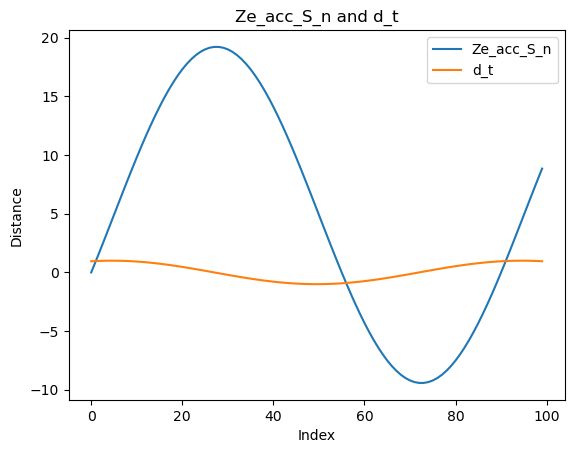

In [26]:
import matplotlib.pyplot as plt
plt.plot(Ze_acc_S_n, label='Ze_acc_S_n')
plt.plot(d_t, label='d_t')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('Ze_acc_S_n and d_t')
plt.legend()

# S_n implementation in oreonspy

In [27]:
# To use np.add.accumulate and make it produce the first element 0, Ze must have the first element 0.

Ze = np.zeros(N + 1)
Ze[1:] = np.linspace(Z, Z_start, N, endpoint=True)  # endpoint=True is not consistent with the oreosnpy code
Ze[0] = 0.

Ze = transform_distances(Ze)

print("Ze[{0}]:".format(len(Ze)))
print(Ze)

Ze_acc_oreonspy = np.add.accumulate(Ze)

print("Ze_acc_oreonspy[{0}]:".format(len(Ze_acc_oreonspy)))
print(Ze_acc_oreonspy)

Ze[101]:
[ 0.00000000e+00  9.51056516e-01  9.70295726e-01  9.84807753e-01
  9.94521895e-01  9.99390827e-01  9.99390827e-01  9.94521895e-01
  9.84807753e-01  9.70295726e-01  9.51056516e-01  9.27183855e-01
  8.98794046e-01  8.66025404e-01  8.29037573e-01  7.88010754e-01
  7.43144825e-01  6.94658370e-01  6.42787610e-01  5.87785252e-01
  5.29919264e-01  4.69471563e-01  4.06736643e-01  3.42020143e-01
  2.75637356e-01  2.07911691e-01  1.39173101e-01  6.97564737e-02
 -2.26621556e-15 -6.97564737e-02 -1.39173101e-01 -2.07911691e-01
 -2.75637356e-01 -3.42020143e-01 -4.06736643e-01 -4.69471563e-01
 -5.29919264e-01 -5.87785252e-01 -6.42787610e-01 -6.94658370e-01
 -7.43144825e-01 -7.88010754e-01 -8.29037573e-01 -8.66025404e-01
 -8.98794046e-01 -9.27183855e-01 -9.51056516e-01 -9.70295726e-01
 -9.84807753e-01 -9.94521895e-01 -9.99390827e-01 -9.99390827e-01
 -9.94521895e-01 -9.84807753e-01 -9.70295726e-01 -9.51056516e-01
 -9.27183855e-01 -8.98794046e-01 -8.66025404e-01 -8.29037573e-01
 -7.88010754e-01

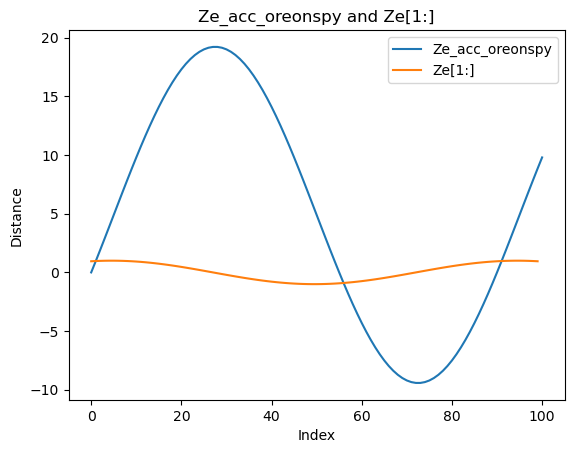

In [28]:
plt.plot(Ze_acc_oreonspy, label='Ze_acc_oreonspy')
plt.plot(Ze[1:], label='Ze[1:]')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('Ze_acc_oreonspy and Ze[1:]')
plt.legend()

# Compare S_n_linear with oreonspy implementation

In [29]:
# Half-product: Distances (just for debug)
print("Ze[1:]-d_t[:] [{}]:".format(len(Ze[1:])))
print(Ze[1:]-d_t[:])

Ze[1:]-d_t[:] [100]:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


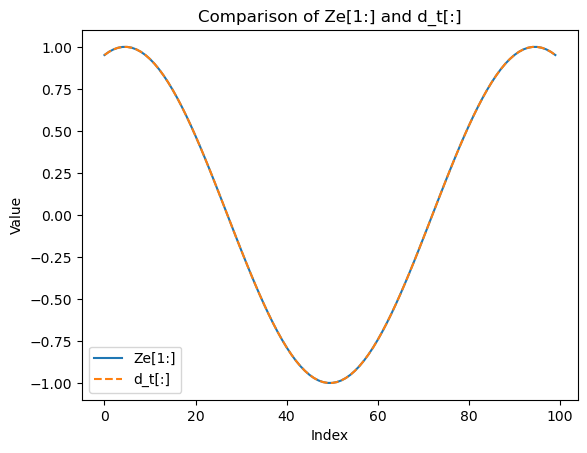

In [30]:
plt.plot(Ze[1:], label='Ze[1:]')
plt.plot(d_t, label='d_t[:]', ls='--')

plt.legend()
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Comparison of Ze[1:] and d_t[:]')
plt.show()

In [31]:
# Final product: Accumulated distances (relevant for calculation)
print("Ze_acc_oreonspy[:-1]-Ze_acc_S_n [{}]:".format(len(Ze_acc_oreonspy[:-1])))
print(Ze_acc_oreonspy[:-1]-Ze_acc_S_n)

Ze_acc_oreonspy[:-1]-Ze_acc_S_n [100]:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


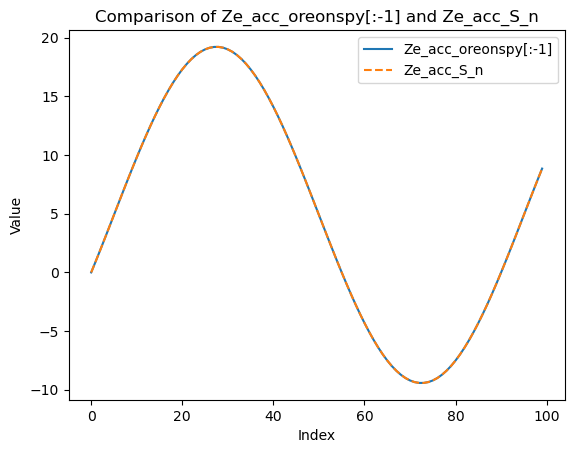

In [32]:
plt.plot(Ze_acc_oreonspy[:-1], label='Ze_acc_oreonspy[:-1]')
plt.plot(Ze_acc_S_n, label='Ze_acc_S_n', ls='--')

plt.legend()
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Comparison of Ze_acc_oreonspy[:-1] and Ze_acc_S_n')
plt.show()

# Conclusion

* To produce correctly ```Ze_acc_oreonspy``` by means of the ```np.add.accumulate()``` distances vector, ```Ze``` must contatin a zero at the first position;
* For the correct solution, the vector ```Ze``` must be produced from ```Z``` to ```Z_start``` with ```N``` steps;
* The above points result in ```Ze_acc_oreonspy``` being longer than ```Ze_acc_S_n``` produced in ```range(N)```;
* After shortening the ```Ze_acc_oreonspy```, the results of both methord are equal.

## Outcome for the simulator

* ```Ze``` must be produced corectly for the ```np.add.accumulate()```;
* The last element of the ```Ze_acc_oreonspy``` must be discarded.